<div style='background-color: #fff7f7; border: 3px solid Red;'>
    <font size="+1" color="Red">
        <b>Please comment and upvote if you like this work!</b>
    </font>
</div>
<div style='background-color: #fff7f7; border: 3px solid Blue;'>
    <font size="+1" color="Red">
        <b>Take a look at the other notebooks in my profile ->
        <a href="https://www.kaggle.com/killa92/code">  Kaggle Notebooks </a></b>
    </font>
</div>    
<div style='background-color: #fff7f7; border: 3px solid yellow;'>
    <font size="+1" color="Red">
        <b><span style='color: green;'>Let's Support Each Other!!</span></b>
    </font>
</div>

<div style='background-color: #fff7f7; border: 2px solid '>
    <font size="+2" color="blue" ><b>🗂1. Install libraries and Download a pre-trained checkpoint 🗂</b></font>
</div>

In [1]:
from IPython import display
display.clear_output()

HOME = "/kaggle/working/"
!git clone https://github.com/SkalskiP/yolov9.git
%cd yolov9
!pip install -r requirements.txt -q
!pip install -q roboflow
!wget -P {HOME}/weights -q https://github.com/WongKinYiu/yolov9/releases/download/v0.1/yolov9-c.pt

Cloning into 'yolov9'...
remote: Enumerating objects: 325, done.
remote: Total 325 (delta 0), reused 0 (delta 0), pack-reused 325 (from 1)
Receiving objects: 100% (325/325), 2.25 MiB | 22.77 MiB/s, done.
Resolving deltas: 100% (162/162), done.
/kaggle/working/yolov9
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.8.1 requires wurlitzer, which is not installed.
jupyterlab 4.1.2 requires jupyter-lsp>=2.0.0, but you have jupyter-lsp 1.5.1 which is incompatible.
jupyterlab-lsp 5.0.3 requires jupyter-lsp>=2.0.0, but you have jupyter-lsp 1.5.1 which is incompatible.
tensorflow 2.15.0 requires keras<2.16,>=2.15.0, but you have keras 3.0.5 which is incompatible.
ydata-profiling 4.6.4 requires numpy<1.26,>=1.16.0, but you have numpy 1.26.4 which is incompatible.


<div style='background-color: #fff7f7; border: 2px solid '>
    <font size="+2" color="blue" ><b>📈 2. Data Analysis 📈</b></font>
</div>

Data analysis is in process...

Data analysis is in process...

Data analysis is in process...



/tmp/ipykernel_26/1082298463.py:108: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(cls_names)


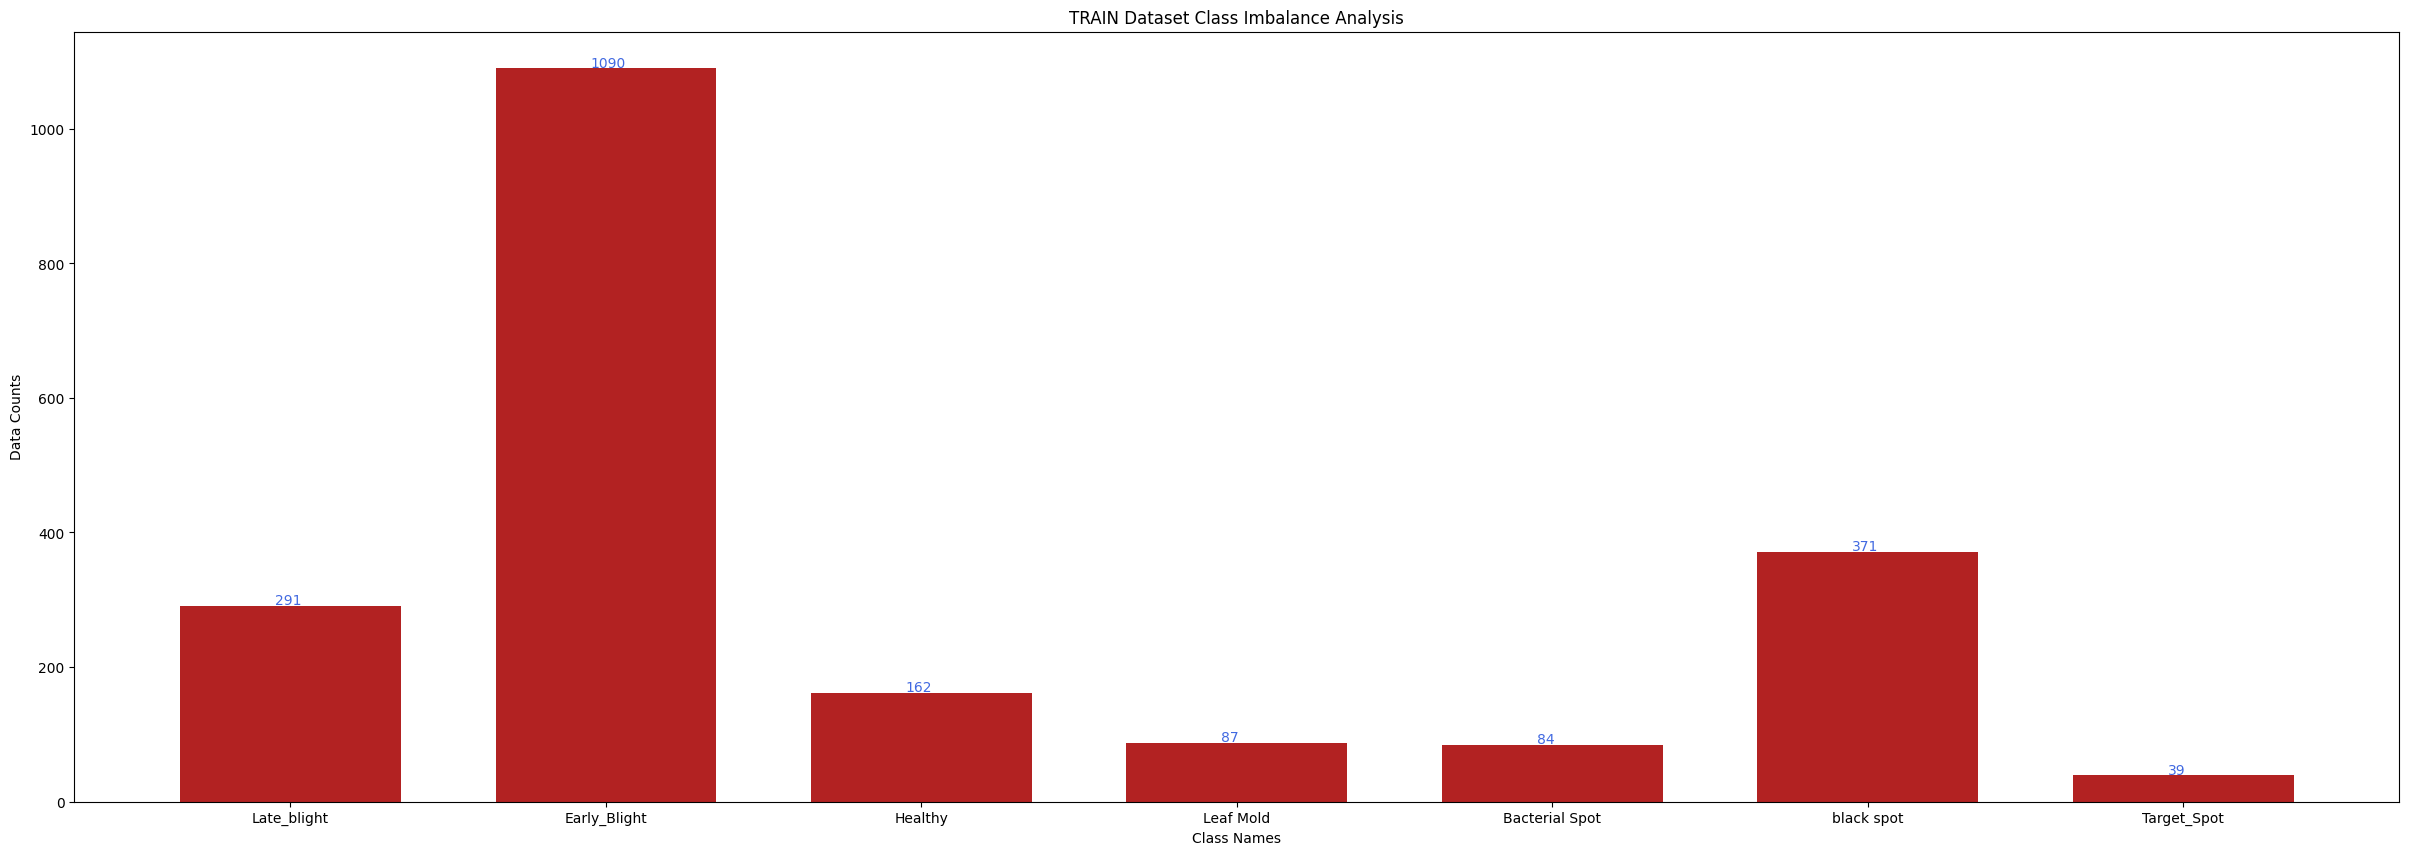

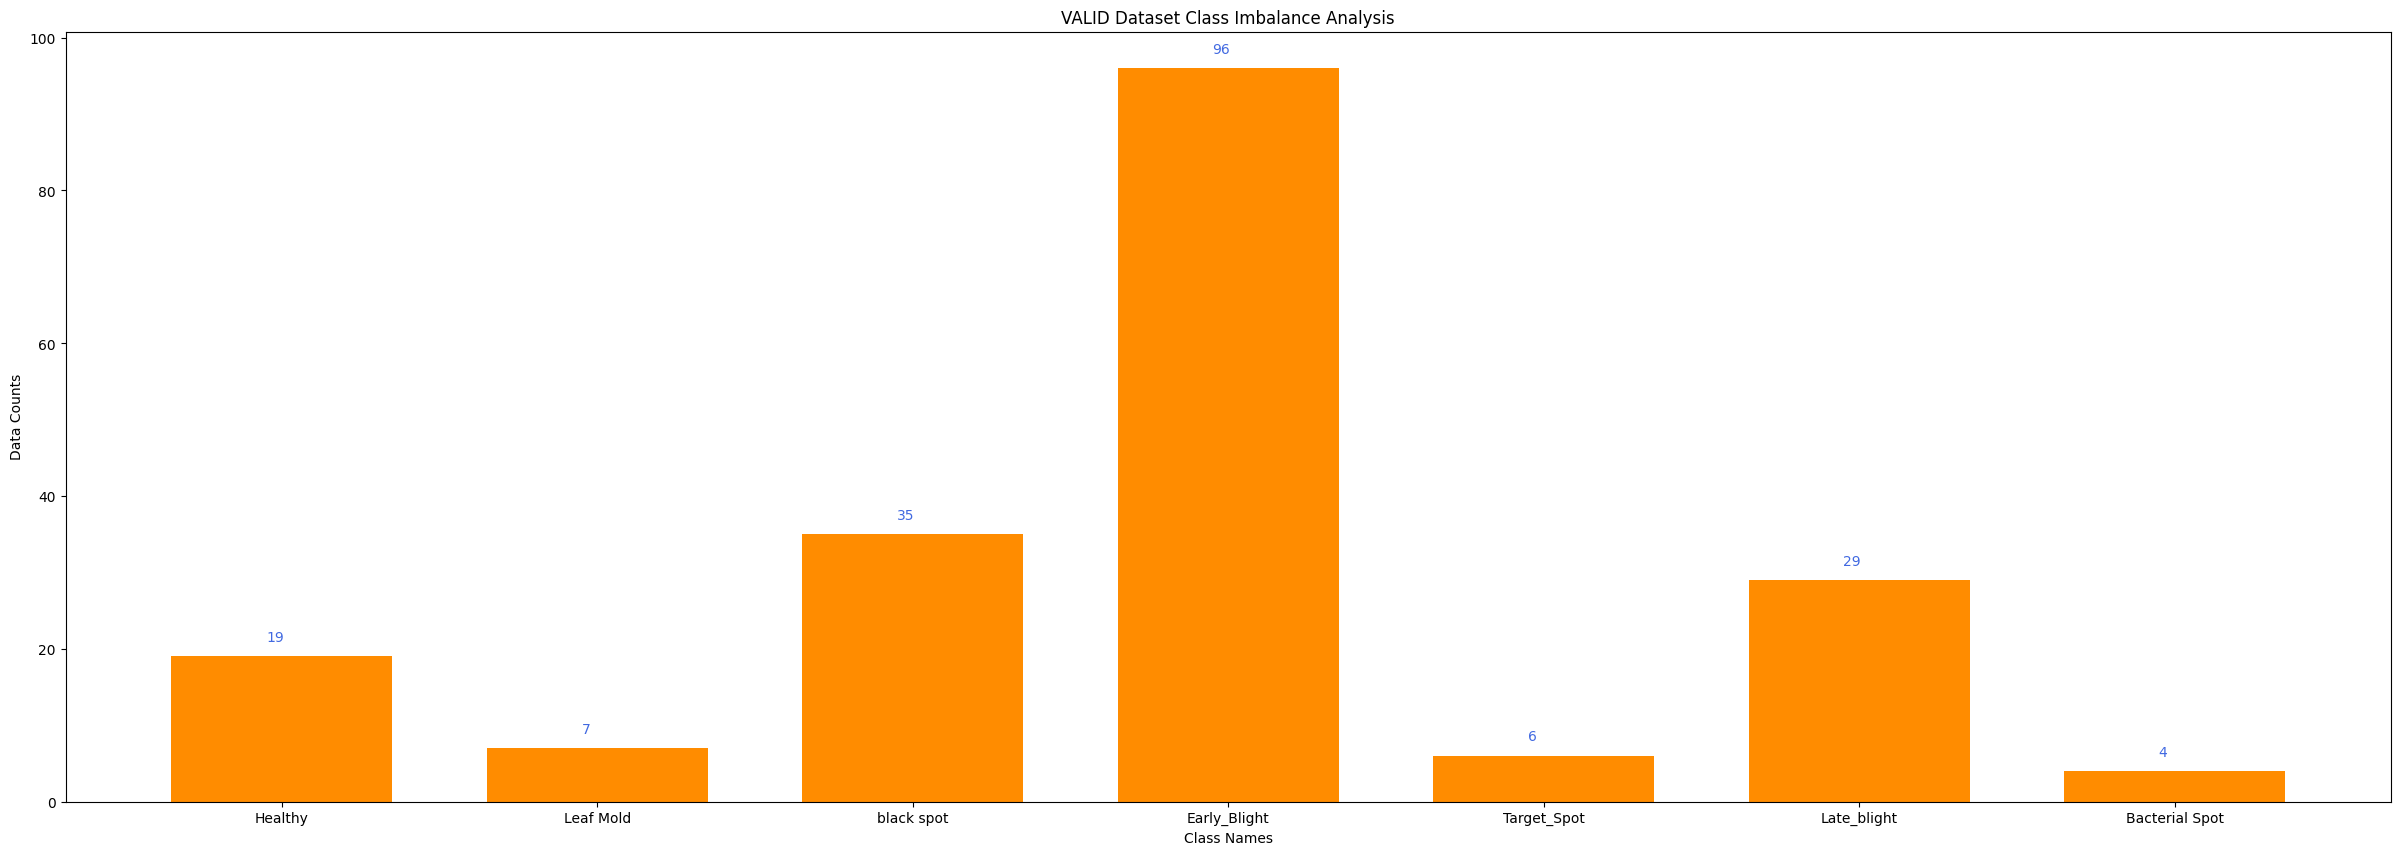

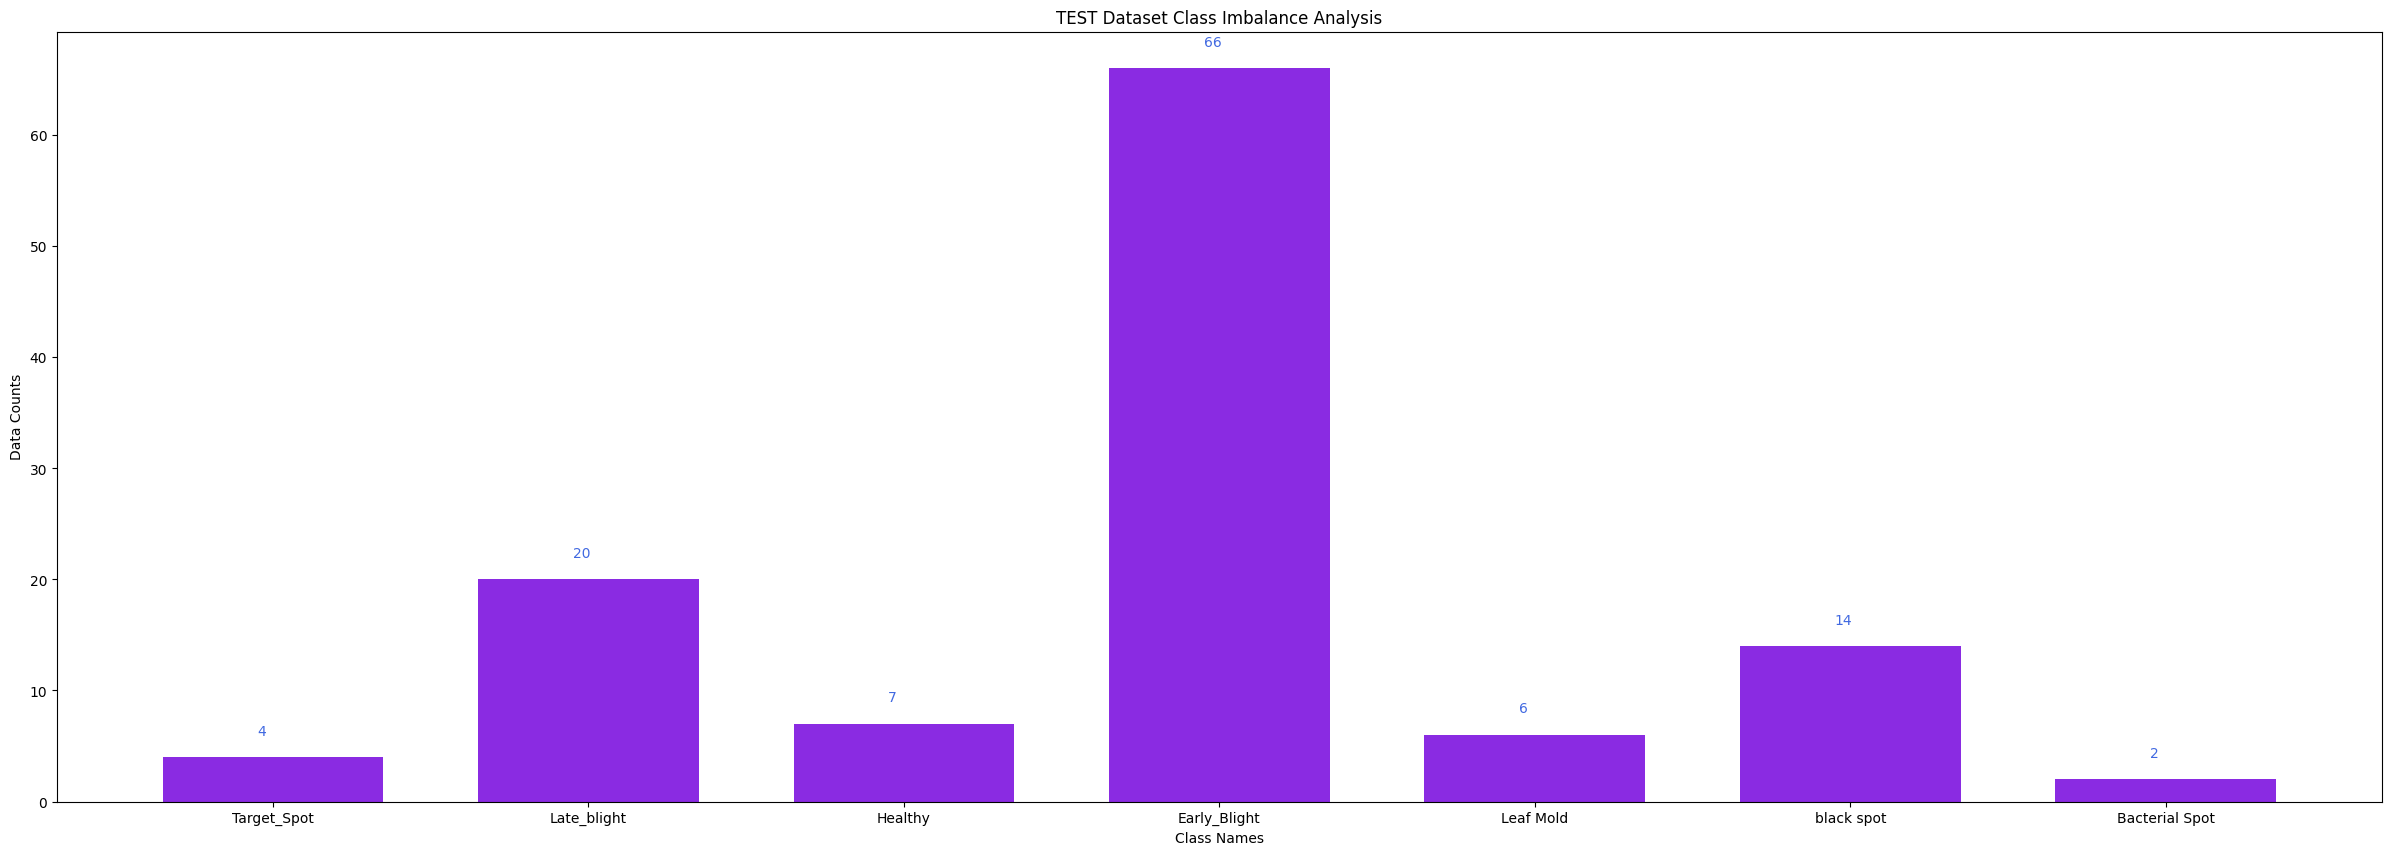

In [2]:
import cv2, yaml, random, numpy as np
from PIL import Image
from matplotlib import pyplot as plt
from torchvision import transforms as T
from glob import glob

class Visualization:

    def __init__(self, root, data_types, n_ims, rows, cmap = None):

        self.n_ims, self.rows, self.root = n_ims, rows, root
        self.cmap, self.data_types  = cmap, data_types
        self.colors = ["firebrick", "darkorange", "blueviolet"]
        
        self.get_cls_names(); self.get_bboxes()        
                
    def get_cls_names(self):

        with open(f"{self.root}/data.yaml", 'r') as file: data = yaml.safe_load(file)      
        # Extract class names
        class_names = data['names']
        
        # Create a dictionary with index as key and class name as value
        self.class_dict = {index: name for index, name in enumerate(class_names)}        
    
    def get_bboxes(self):

        self.vis_datas, self.analysis_datas, self.im_paths = {}, {}, {}
        for data_type in self.data_types:
            all_bboxes, all_analysis_datas = [], {}
            im_paths = glob(f"{self.root}/{data_type}/images/*")
            for idx, im_path in enumerate(im_paths):
                bboxes = []
                # if idx == 3: break
                if ".png" in im_path: im_path = im_path.replace(".png", ".txt")
                elif ".jpg" in im_path: im_path = im_path.replace(".jpg", ".txt")
                lbl_path  = im_path.replace("images", "labels")
                meta_data = open(lbl_path).readlines()
                for data in meta_data:
                    # Split the string by space and strip the newline character
                    # Change here 
                    parts = data.strip().split()[:5]
                    cls_name = self.class_dict[int(parts[0])]
                    # Convert first element to integer and the rest to float
                    bboxes.append([cls_name] + [float(x) for x in parts[1:]])
                    if cls_name not in all_analysis_datas: all_analysis_datas[cls_name] = 1
                    else: all_analysis_datas[cls_name] += 1
                all_bboxes.append(bboxes)
                    
            self.vis_datas[data_type] = all_bboxes; self.analysis_datas[data_type] = all_analysis_datas; self.im_paths[data_type] = im_paths
    
    def plot(self, rows, cols, count, im_path, bboxes):
    
        plt.subplot(rows, cols, count)
        or_im = np.array(Image.open(im_path).convert("RGB"))
        height, width, _ = or_im.shape

        for bbox in bboxes:
            
            class_id, x_center, y_center, w, h = bbox

            # Convert YOLO format to pixel values
            x_min = int((x_center - w / 2) * width)  # x_min
            y_min = int((y_center - h / 2) * height)  # y_min
            x_max = int((x_center + w / 2) * width)  # x_max
            y_max = int((y_center + h / 2) * height)  # y_max
            
            color = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))
            cv2.rectangle(img = or_im, pt1 = (x_min, y_min), pt2 = (x_max, y_max), color = color, thickness = 3)
        plt.imshow(or_im)
        plt.axis("off"); plt.title(f"There are {len(bboxes)} object(s) in the image.")
        
        return count + 1

    def vis(self, save_name):

        print(f"{save_name.upper()} Data Visualization is in process...\n")
        assert self.cmap in ["rgb", "gray"], "Please choose rgb or gray cmap"
        if self.cmap == "rgb": cmap = "viridis"
        cols = self.n_ims // self.rows; count = 1
        
        plt.figure(figsize = (25, 20))
                
        indices = [random.randint(a = 0, b = len(self.vis_datas[save_name]) - 1) for _ in range(self.n_ims)]

        for idx, index in enumerate(indices):
        
            if count == self.n_ims + 1: break
            
            im_path, bboxes = self.im_paths[save_name][index], self.vis_datas[save_name][index]

            count = self.plot(self.rows, cols, count, im_path = im_path, bboxes = bboxes)
            
        plt.show()

    def data_analysis(self, save_name, color):

        print("Data analysis is in process...\n")
        
        width, text_width, text_height = 0.7, 0.05, 2
        cls_names = list(self.analysis_datas[save_name].keys()); counts = list(self.analysis_datas[save_name].values())
        
        _, ax = plt.subplots(figsize = (30, 10))
        indices = np.arange(len(counts))

        ax.bar(indices, counts, width, color = color)
        ax.set_xlabel("Class Names", color = "black")
        ax.set_xticklabels(cls_names)
        ax.set(xticks = indices, xticklabels = cls_names)
        ax.set_ylabel("Data Counts", color = "black")
        ax.set_title(f"{save_name.upper()} Dataset Class Imbalance Analysis")

        for i, v in enumerate(counts): ax.text(i - text_width, v + text_height, str(v), color = "royalblue")
    
    def visualization(self): [self.vis(save_name) for save_name in self.data_types]
        
    def analysis(self): [self.data_analysis(save_name, color) for (save_name, color) in zip(self.data_types, self.colors)]

root = "/kaggle/input/tomato-leaf-diseases-detection-computer-vision"
vis = Visualization(root = root, data_types = ["train", "valid", "test"], n_ims = 20, rows = 5, cmap = "rgb")
vis.analysis()

<div style='background-color: #fff7f7; border: 2px solid '>
    <font size="+2" color="blue" ><b>📊 3. Data Visualization 📊</b></font>
</div>

TRAIN Data Visualization is in process...



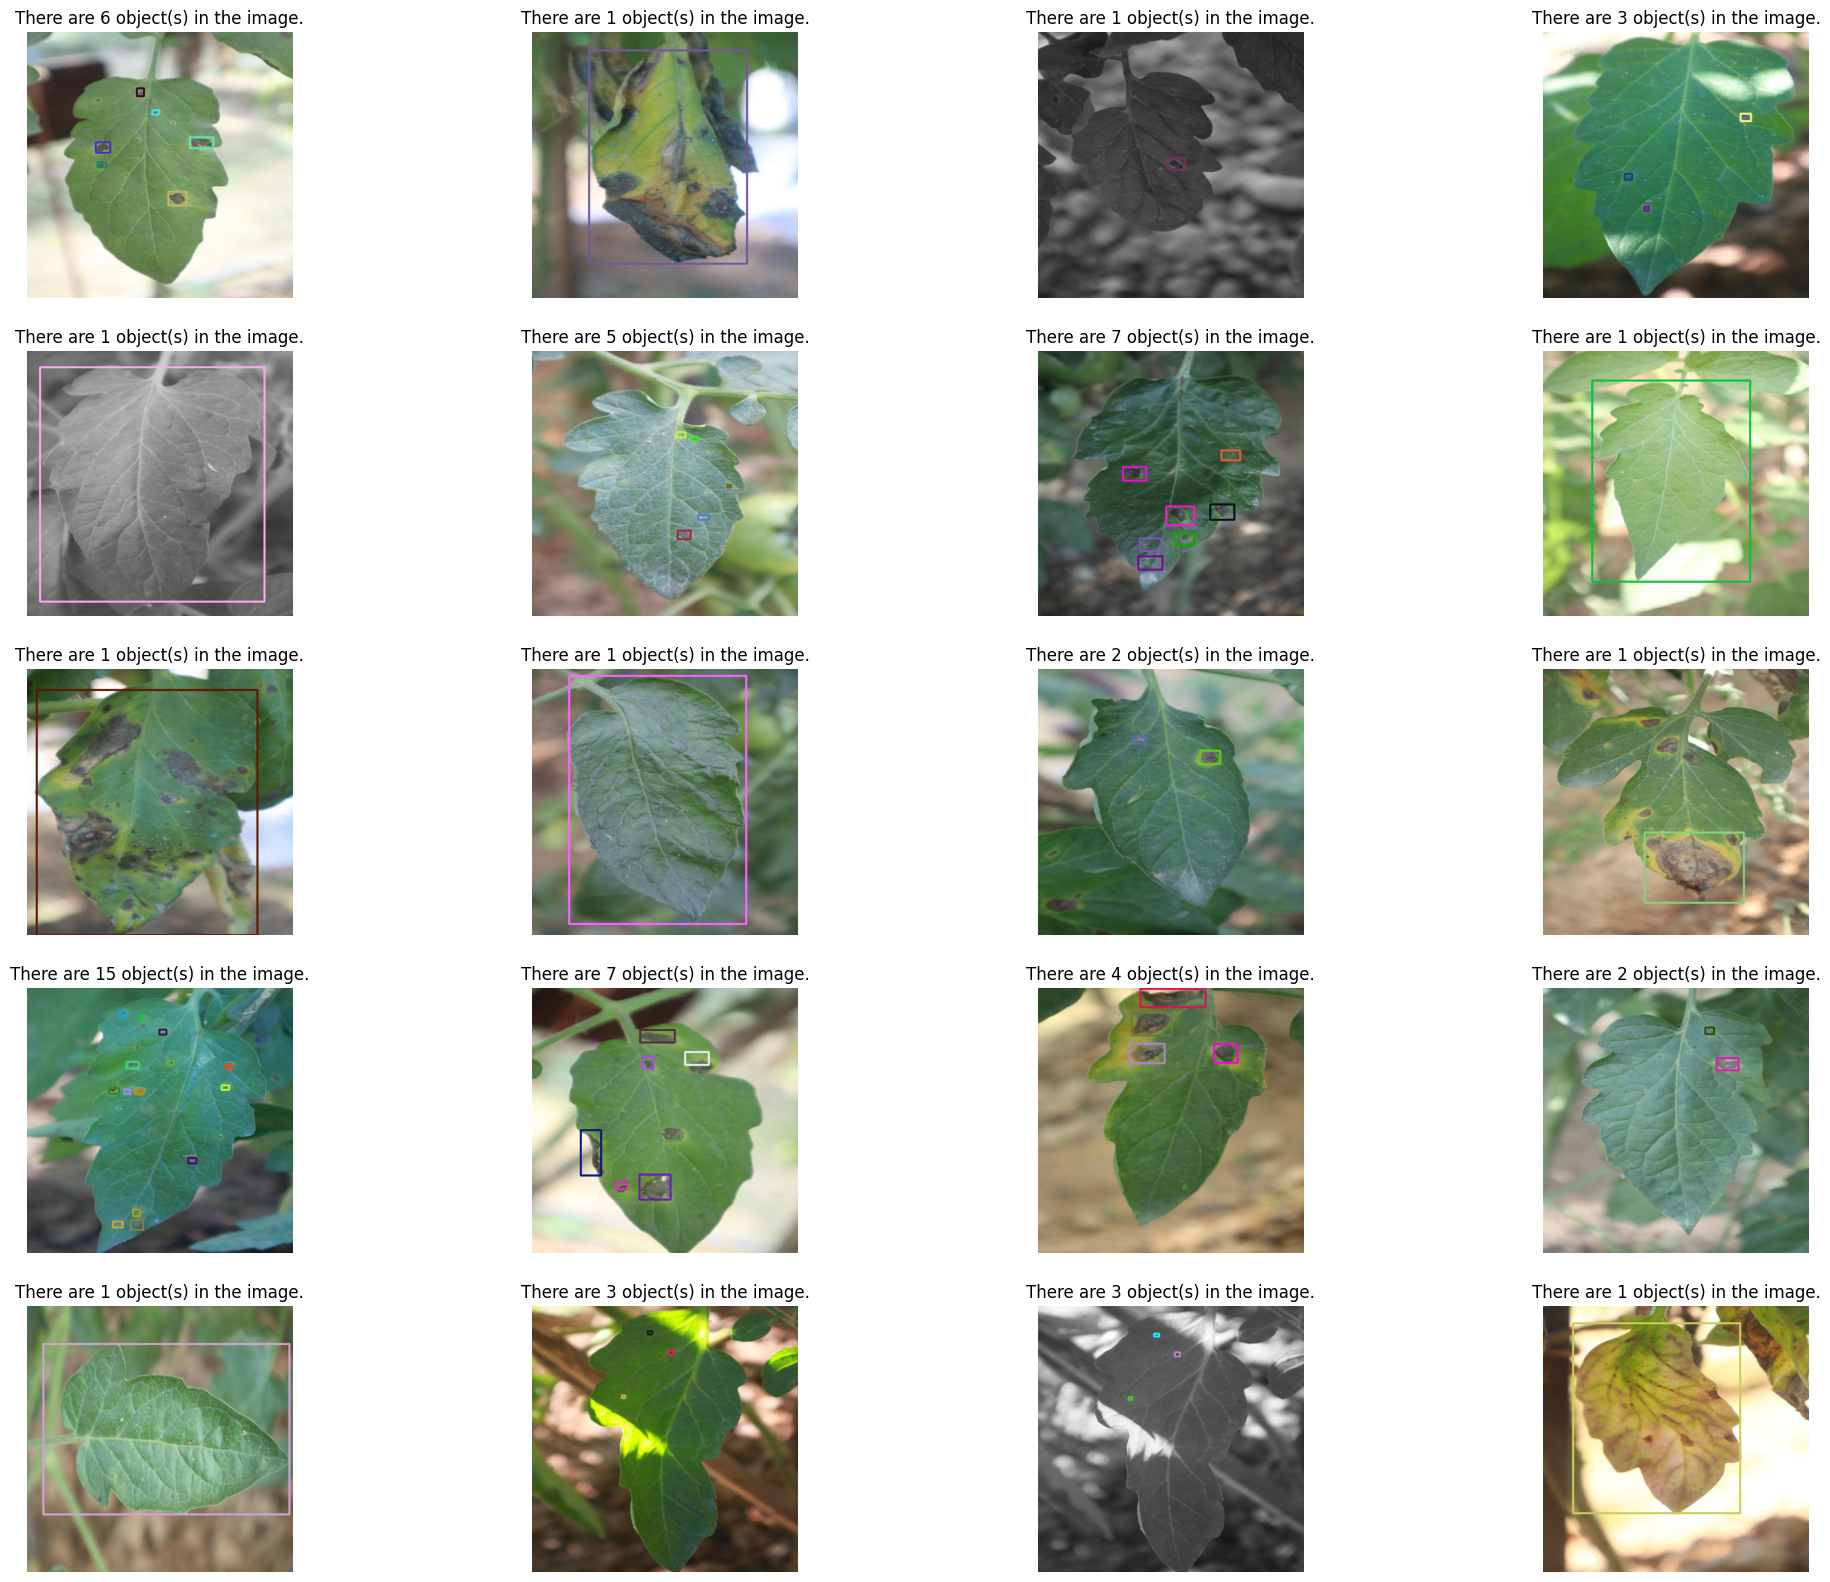

VALID Data Visualization is in process...



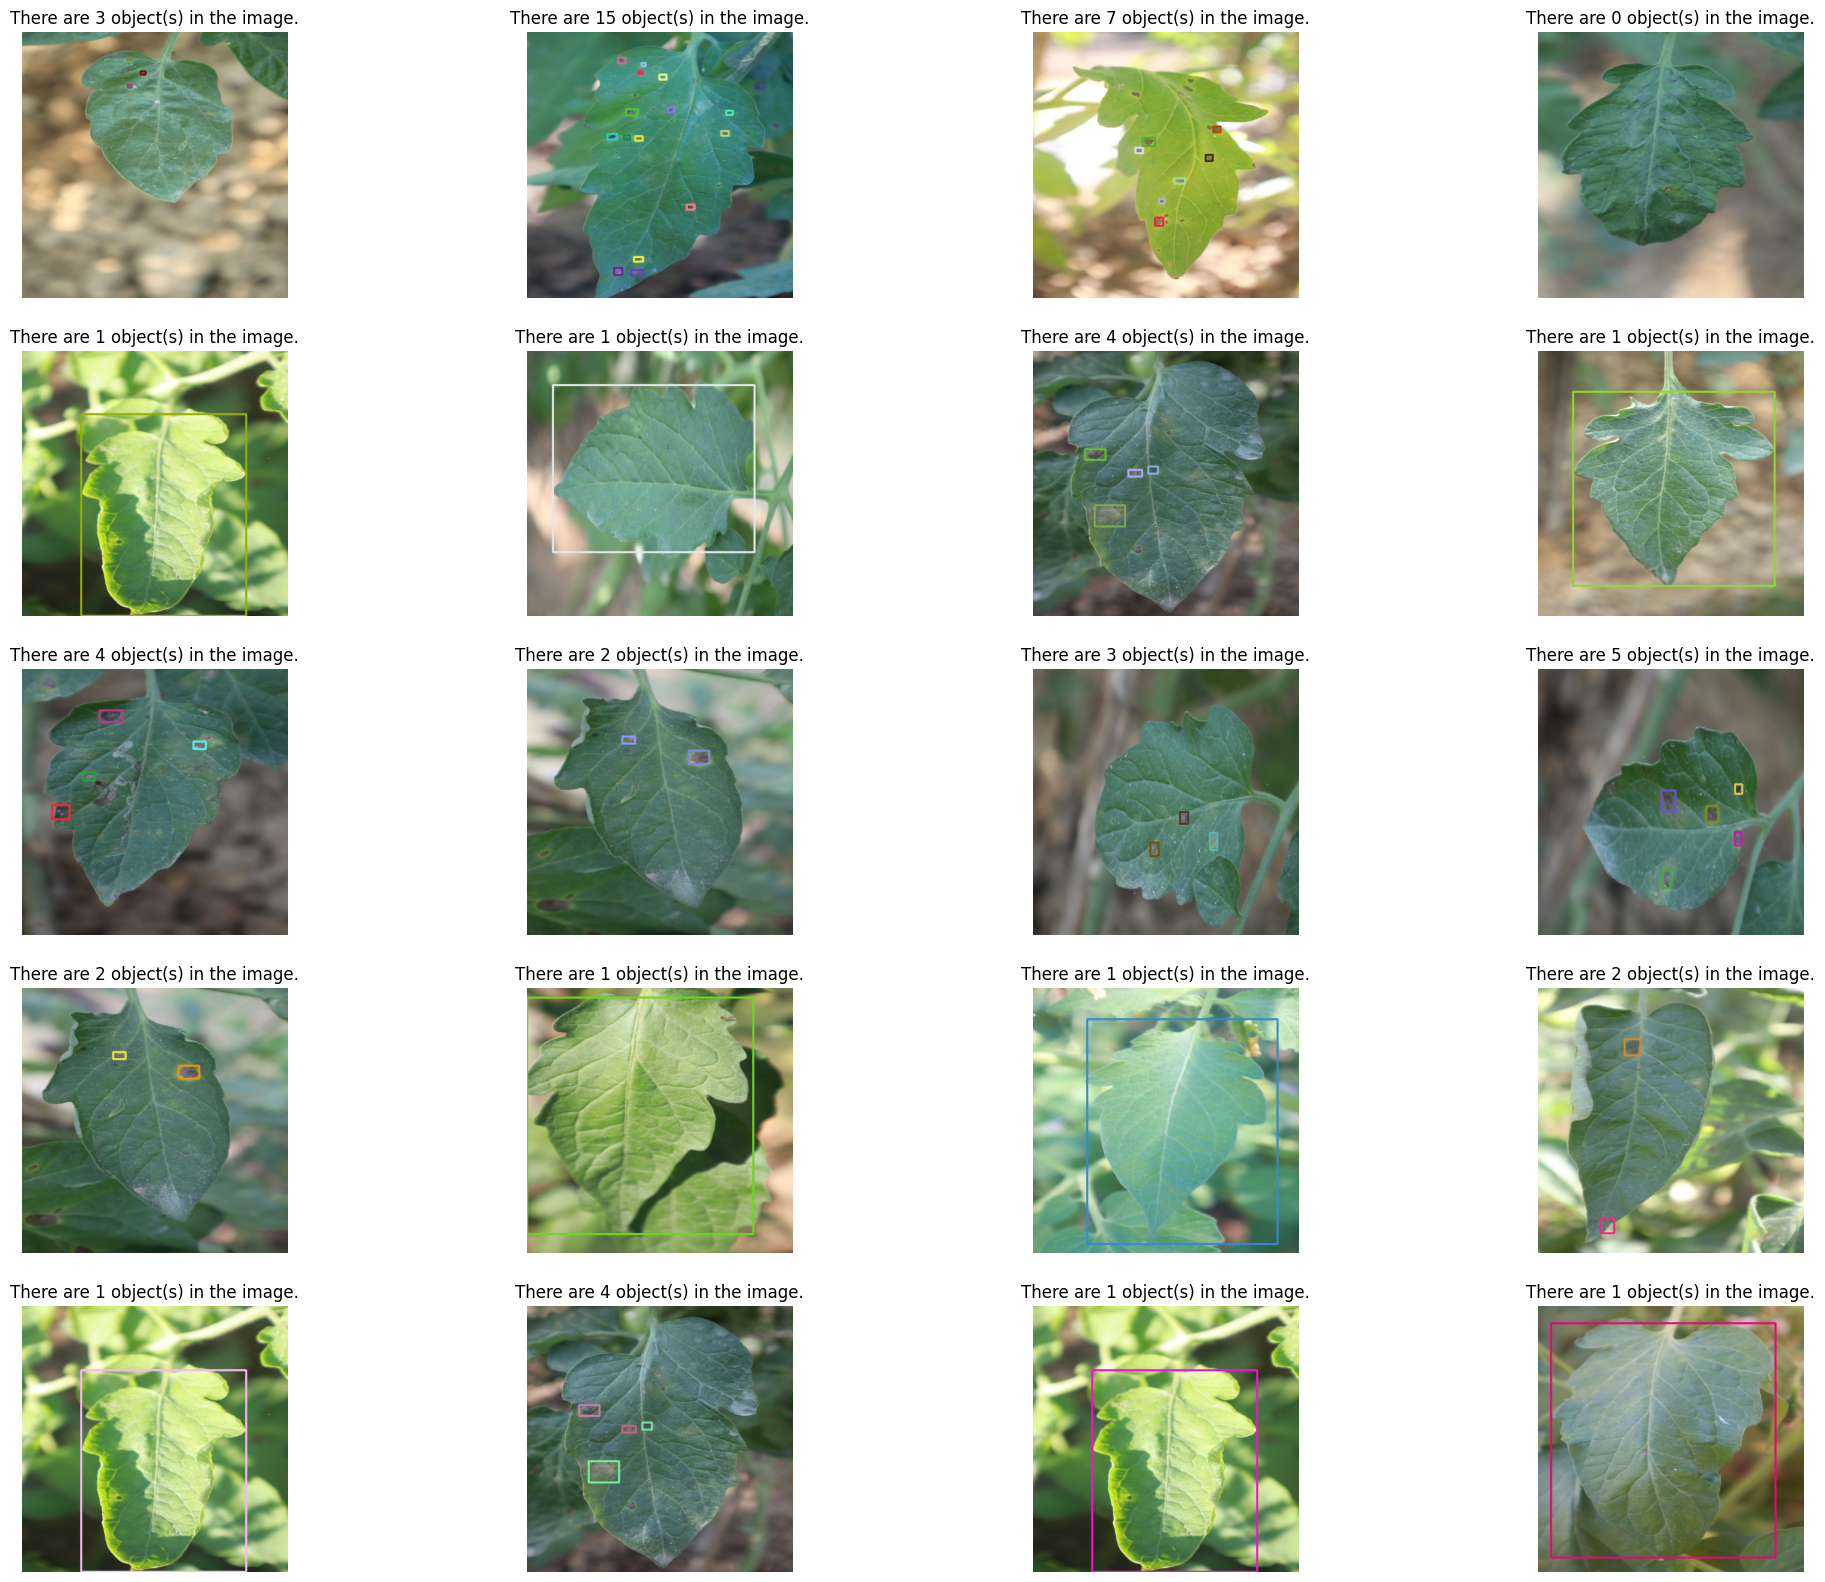

TEST Data Visualization is in process...



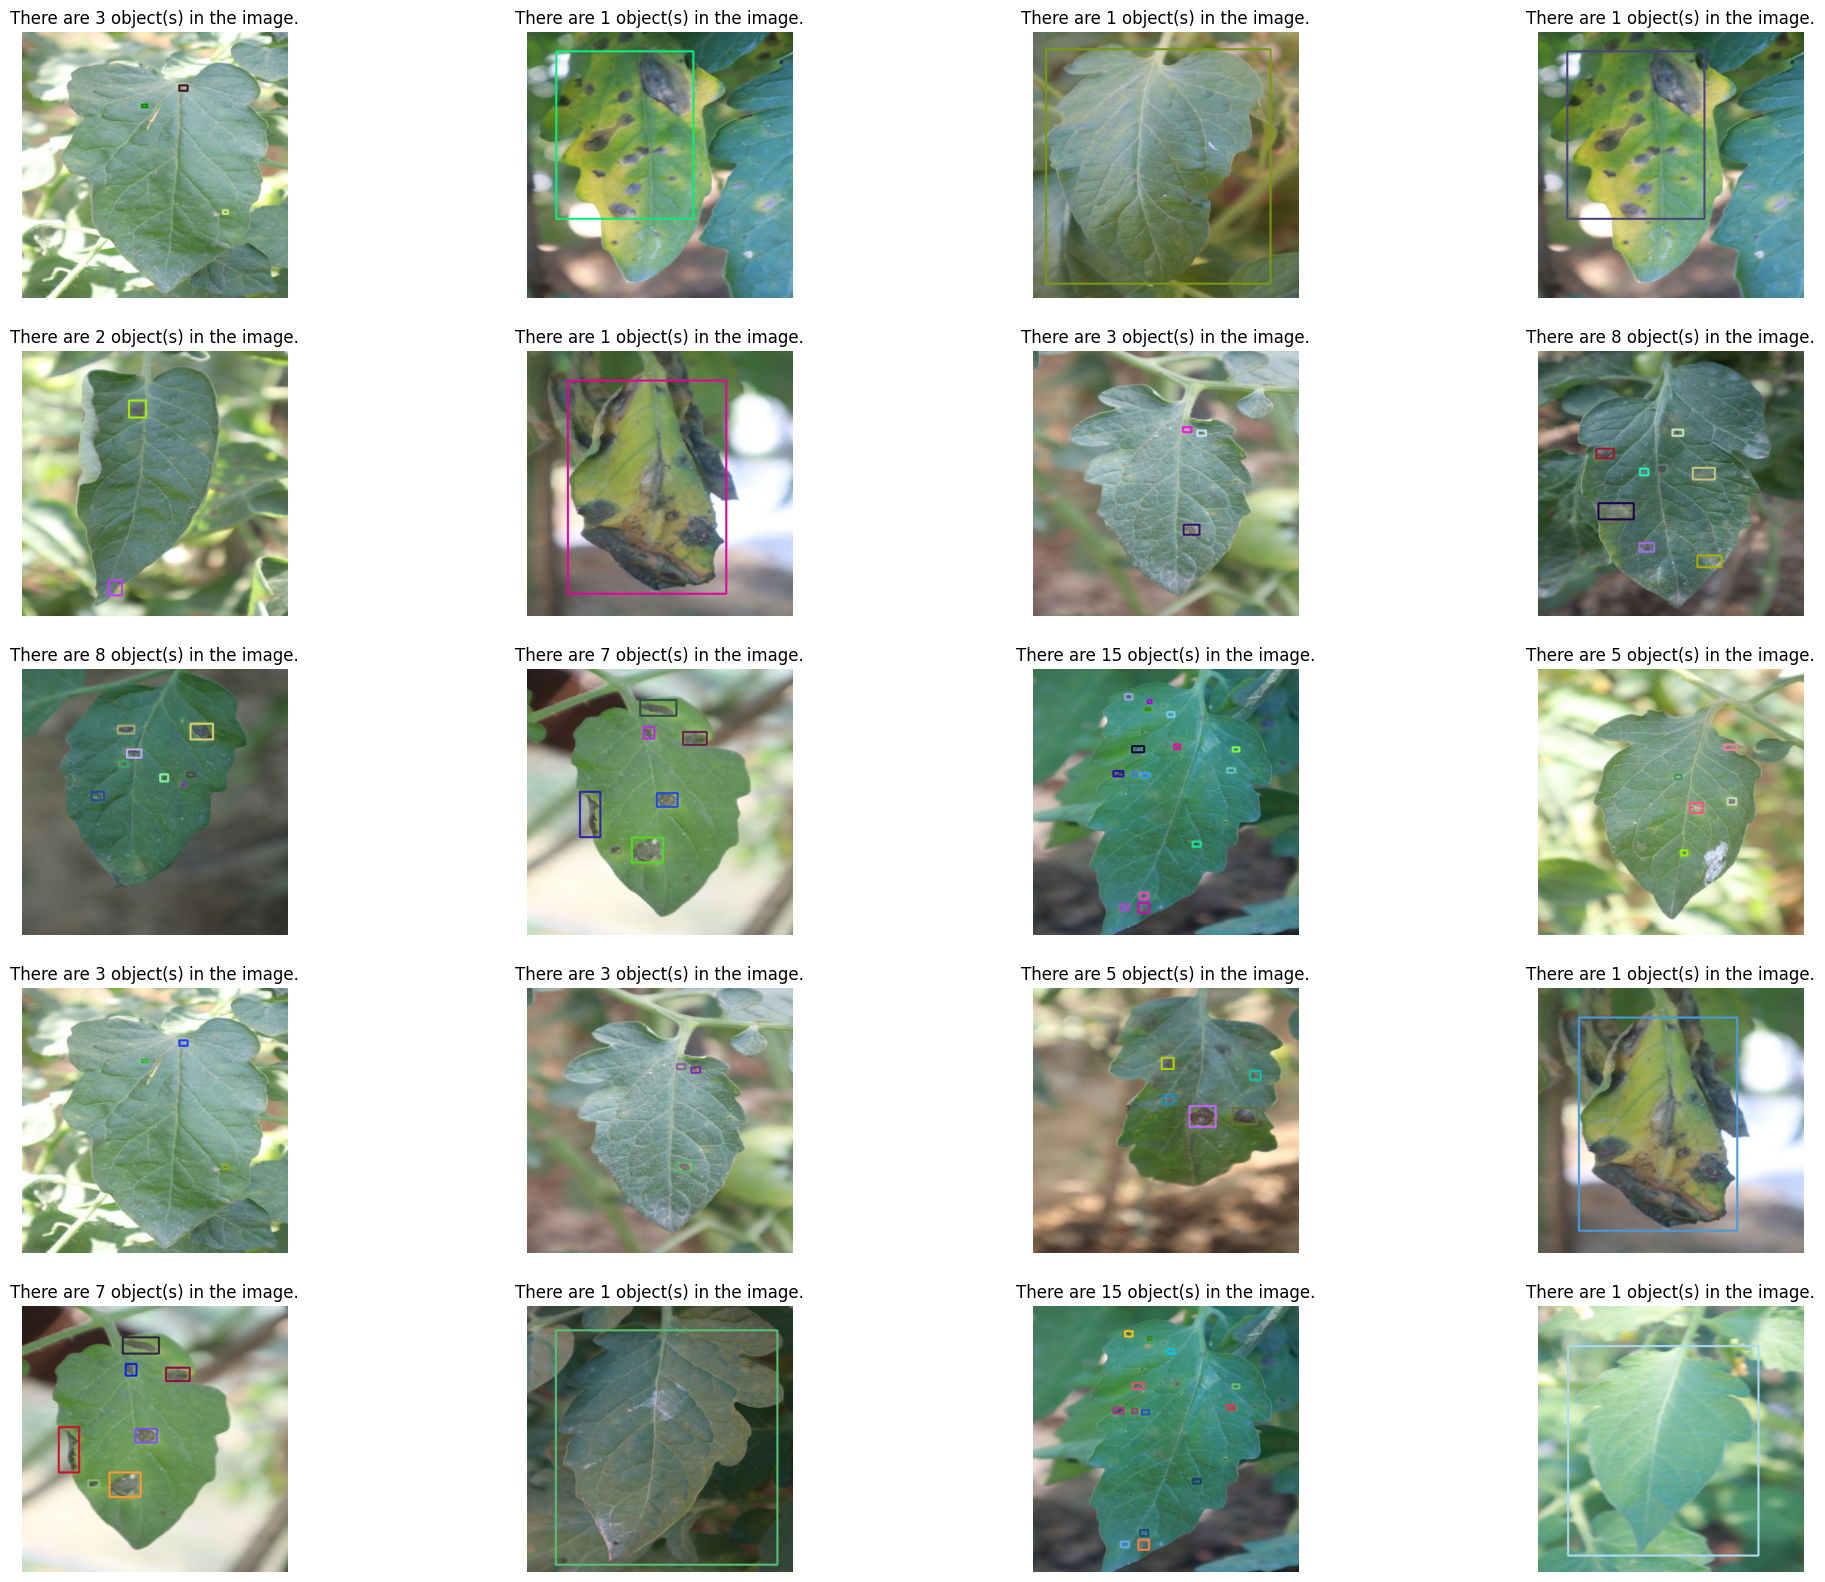

In [3]:
vis.visualization()

In [4]:
# Load YAML content into a Python dictionary
yml_file_path = f"{root}/data.yaml"

with open(yml_file_path, 'r') as file:
    data = yaml.safe_load(file)
# Update the paths
data['train'] = f'{root}/train/images'
data['val'] = f'{root}/valid/images'
data['test'] = f'{root}/test/images'

print(data)
# Save the updated YAML content to a file
output_path = '/kaggle/working/updated_config.yml'
with open(output_path, 'w') as file: yaml.dump(data, file, default_flow_style=False)

{'train': '/kaggle/input/tomato-leaf-diseases-detection-computer-vision/train/images', 'val': '/kaggle/input/tomato-leaf-diseases-detection-computer-vision/valid/images', 'test': '/kaggle/input/tomato-leaf-diseases-detection-computer-vision/test/images', 'nc': 7, 'names': ['Bacterial Spot', 'Early_Blight', 'Healthy', 'Late_blight', 'Leaf Mold', 'Target_Spot', 'black spot'], 'roboflow': {'workspace': 'sylhet-agricultural-university', 'project': 'tomato-leaf-diseases-detect', 'version': 3, 'license': 'Public Domain', 'url': 'https://universe.roboflow.com/sylhet-agricultural-university/tomato-leaf-diseases-detect/dataset/3'}}


<div style='background-color: #fff7f7; border: 2px solid '>
    <font size="+2" color="blue" ><b>✨ 4. AI Model Train✨</b></font>
</div>

In [5]:
%cd {HOME}/yolov9

!python train_dual.py \
--batch 4 --epochs 10 --img 640 --device 0 --min-items 0 --close-mosaic 15 \
--data {output_path} \
--weights {HOME}/weights/yolov9-c.pt \
--cfg models/detect/yolov9-c.yaml \
--hyp hyp.scratch-high.yaml 

/kaggle/working/yolov9
2025-01-27 11:44:31.575248: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-27 11:44:31.575366: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-27 11:44:31.707737: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 
wandb: W&B disabled due to login timeout.
train_dual: weights=/kaggle/working//weights/yolov9-c.pt, cfg=models/detect/yolov9-c.yaml, data=/kaggle/working/updated_config.yml, hyp=hyp.scra

<div style='background-color: #fff7f7; border: 2px solid '>
    <font size="+2" color="blue" ><b>😍 5. Learning Curves 😍</b></font>
</div>


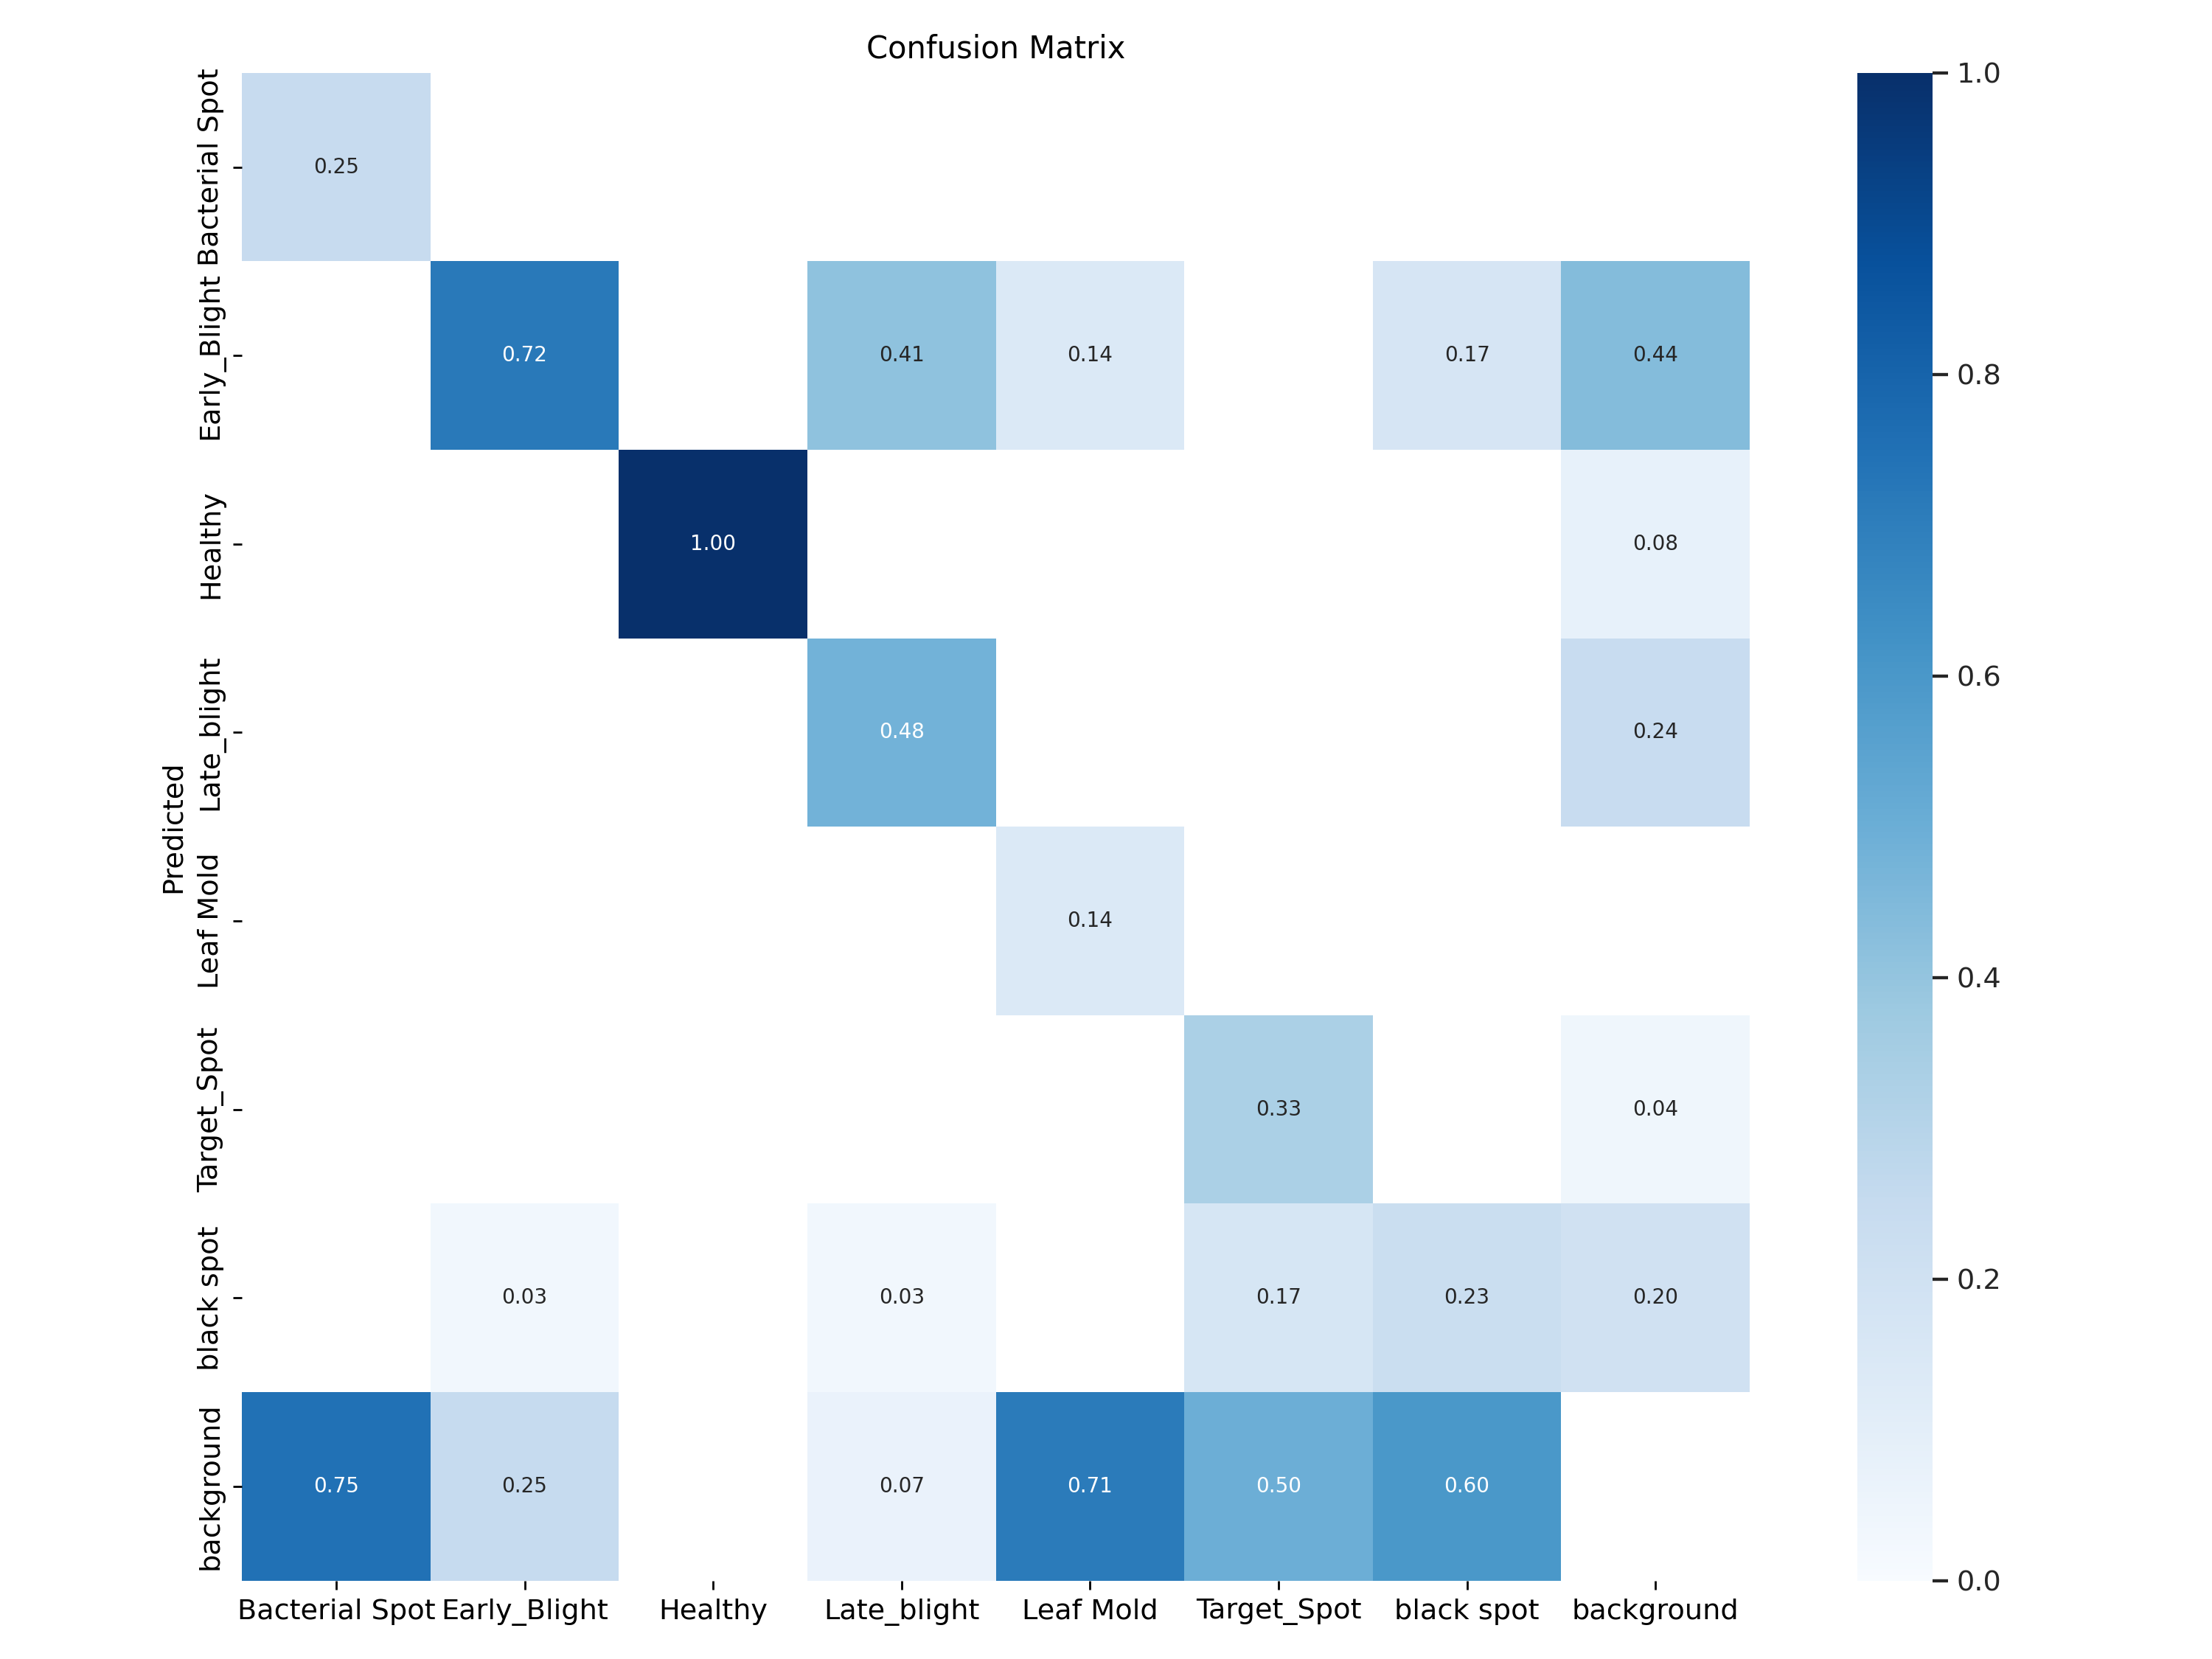

In [6]:
from PIL import Image
Image.open(f"{HOME}yolov9/runs/train/exp/confusion_matrix.png")

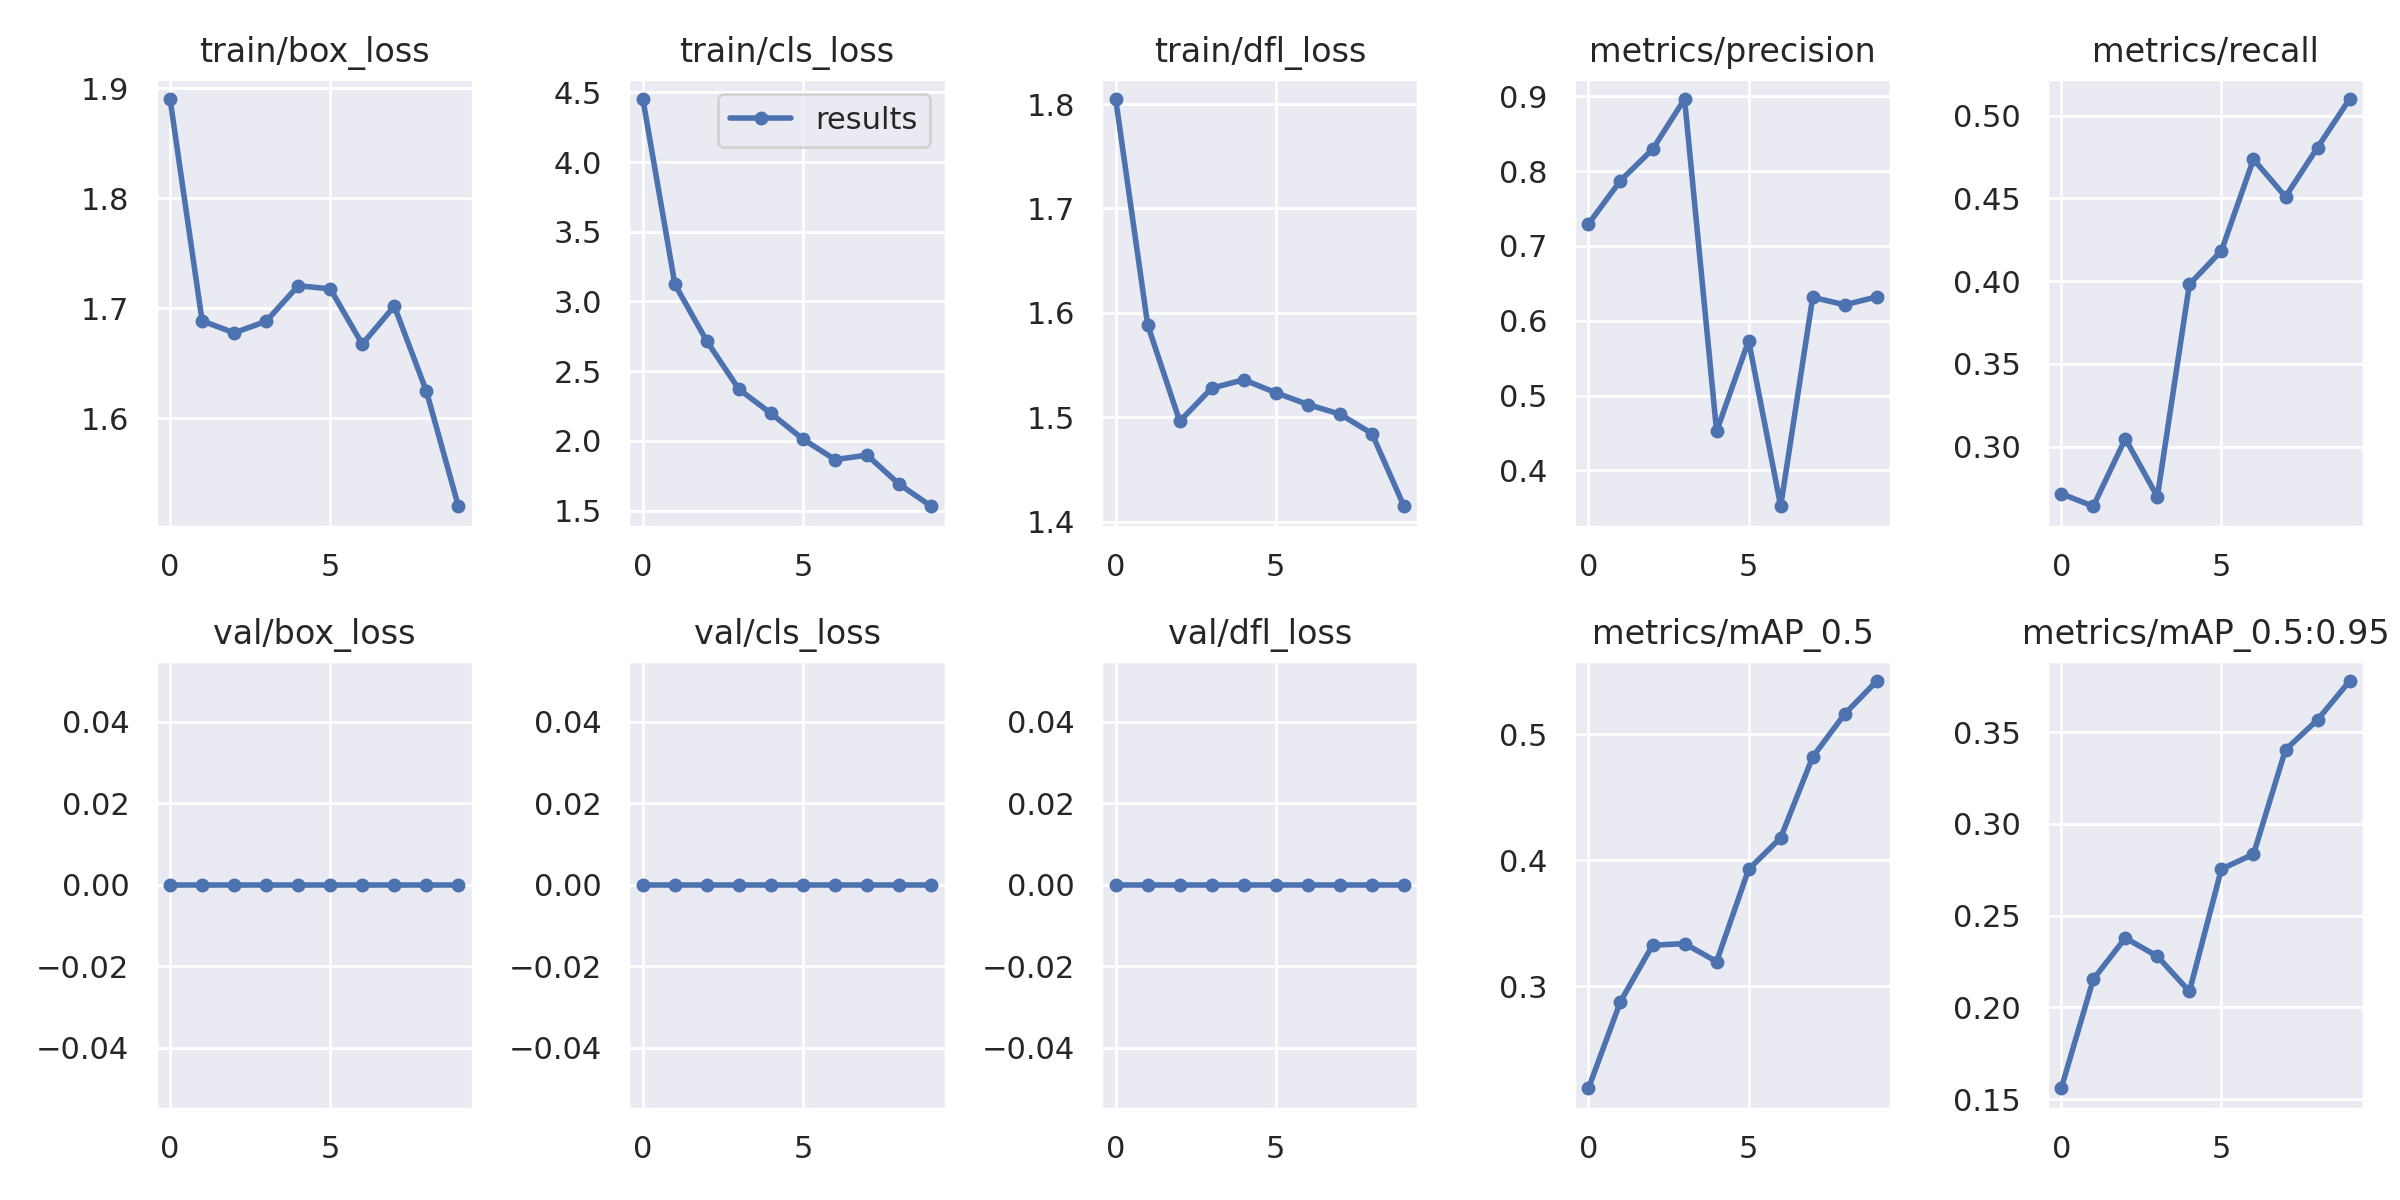

In [7]:
Image.open(f"{HOME}yolov9/runs/train/exp/results.png")

<div style='background-color: #fff7f7; border: 2px solid '>
    <font size="+2" color="blue" ><b>✅6. Inference with Test Dataset✅</b></font>
</div>

In [8]:
%cd {HOME}/yolov9

!python val_dual.py \
--img 640 --batch 16 --conf 0.3 --iou 0.5 --device 0 \
--data {HOME}/yolov9/data.yaml \
--weights {HOME}/yolov9/runs/train/exp/weights/best.pt

/kaggle/working/yolov9
Traceback (most recent call last):
  File "/kaggle/working/yolov9/val_dual.py", line 392, in <module>
    opt = parse_opt()
  File "/kaggle/working/yolov9/val_dual.py", line 351, in parse_opt
    opt.data = check_yaml(opt.data)  # check YAML
  File "/kaggle/working/yolov9/utils/general.py", line 452, in check_yaml
    return check_file(file, suffix)
  File "/kaggle/working/yolov9/utils/general.py", line 478, in check_file
    assert len(files), f'File not found: {file}'  # assert file was found
AssertionError: File not found: /kaggle/working//yolov9/data.yaml


In [9]:
!python detect.py \
--img 640 --conf 0.3 --device 0 \
--weights {HOME}/yolov9/runs/train/exp/weights/best.pt \
--source {HOME}/yolov9/test/images

detect: weights=['/kaggle/working//yolov9/runs/train/exp/weights/best.pt'], source=/kaggle/working//yolov9/test/images, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.3, iou_thres=0.45, max_det=1000, device=0, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 1e33dbb Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
yolov9-c summary: 724 layers, 50972490 parameters, 0 gradients, 237.7 GFLOPs
Traceback (most recent call last):
  File "/kaggle/working/yolov9/detect.py", line 232, in <module>
    main(opt)
  File "/kaggle/working/yolov9/detect.py", line 227, in main
    run(**vars(opt))
  File "/opt/conda/lib/python3.10/site-packages/torch/utils/_contextlib.py", line 115, in decorate_context
    return fun

In [10]:
from glob import glob
from PIL import Image
from matplotlib import pyplot as plt

for image_path in glob(f'{HOME}/yolov9/runs/detect/exp/*.jpg')[:5]:
      plt.imshow(Image.open(image_path)); plt.axis("off"); plt.show()
      print("\n")